# Within-person temporal model comparison

This notebook compares population-level and individualized PPGR models using five-fold, temporally blocked validation within each participant, with a six-hour embargo. Model fitting excludes standardized meals; validation summaries cover all validation meals and standardized meals separately.

## Notebook flow

1. Define the temporal cross-validation design and six linear, XGBoost, and mixed-effects model variants.
2. Fit each model and retain out-of-fold predictions for the four PPGR outcomes.
3. Summarize outcome-specific and multivariate prediction performance.
4. Export the comparison table and generate the performance figure.
5. Calculate participant-level and demographic-subgroup diagnostics and standardized-meal comparisons.

## Outputs

CSV files written to `Results/`:

| File | Contents |
| --- | --- |
| `model_comparison_within_participant_CV.csv` | Outcome-specific R² and Pearson correlations, plus uniform-average multivariate R², by model and validation subset. |

The model-comparison figure is saved as `Figures/panel_2_model_comparison.svg`.

## 1. Setup

Resolve project paths, import the modeling utilities, and load the common prepared meal-level dataset.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, Code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "Code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import xgboost as xgb
from mmer import MixedEffectEstimator
from sklearn.model_selection import BaseCrossValidator, GroupKFold
from tqdm import tqdm

In [3]:
from utils import (
    LeavePercentTimeOut,
    build_design_mats,
    cols_for,
    ensure_cols,
    evaluate_models,
    load_and_prepare_data,
    make_tag,
    make_xgb,
    save_performance,
    show_performance,
)

In [4]:
meta_data, data, id_to_subject_key, clusters = load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

print(f"Prepared {len(data):,} meals from {data['subject_key'].nunique():,} participants.")

data shape : (54987, 133)
Prepared 54,987 meals from 992 participants.


## 2. Temporal cross-validation

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from tqdm import tqdm
import xgboost as xgb
import statsmodels.api as sm
import logging
import statsmodels.formula.api as smf

from mmer import MixedEffectEstimator

In [6]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression

groups = clusters.to_numpy()


results_list = []

models = ["LR", "LMMER_rand_int", "LMMER_full", "XGBoost", 
          "MMER_XGBoost", 
          "MMER_XGBoost_MI"
         ]

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"] # positive_iAUC

predictions_with_features_all_models = data.copy()

# Column-naming helpers: each (model, config) gets its own namespace ("tag")
SUFFIXES = ["true_z", "pred_z", "true", "pred", "pred_fixed_z", "pred_fixed"]

run_tags = []   

remove_features = ["demographics"]

# CV setup
cv = LeavePercentTimeOut(n_splits=5, embargo=pd.Timedelta("6h"), random_state=42)

for model_name in models:
    for std_mode in [True]:
        for interactions in [[False]]:
            for mundlak_corr in [False]:

                # ---- namespace for THIS run -------------------------------
                tag = make_tag(model_name, std_mode, interactions, mundlak_corr)
                cmap = cols_for(tag, prediction_metrics)
                data = ensure_cols(data, cmap, tag)
                run_tags.append(tag)

                all_y_true, all_y_pred, all_y_pred_fixed = [], [], []
                print(f"\nRunning Cross-Validation for {tag}...")

                pbar = tqdm(cv.split(data, data["net_iAUC"], groups=groups),
                            total=cv.get_n_splits(),
                            desc=f"{tag} CV", unit="fold",
                            position=1, ncols=100, dynamic_ncols=False)

                for fold, (train_idx, val_idx) in enumerate(pbar):

                    if model_name == 'MMER_XGBoost':
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, _, _= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                        )
                        y_pred_full = y_pred_fixed = None
                        xgb_fe = make_xgb()
                        model = MixedEffectEstimator(xgb_fe, max_iter=50,
                                                     slq_steps=40, tol=1e-07, n_jobs=8)

                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train)
                        if y_train_mmer.ndim == 1:
                            y_train_mmer = y_train_mmer.reshape(-1, 1)

                        result = model.fit(X_train, y_train_mmer, groups_train_mmer,
                                           random_slopes=([0, 1, 2, 3],))

                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full  = result.predict(X_val, groups=groups_val_mmer)
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == 'MMER_XGBoost_MI':
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, _, _= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                        )
                        y_pred_full = y_pred_fixed = None
                        xgb_fe = make_xgb()
                        model = MixedEffectEstimator(xgb_fe, max_iter=50,
                                                     slq_steps=40, tol=1e-07, n_jobs=8)

                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train)
                        if y_train_mmer.ndim == 1:
                            y_train_mmer = y_train_mmer.reshape(-1, 1)

                        result = model.fit(X_train, y_train_mmer, groups_train_mmer) # no random slopes

                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full  = result.predict(X_val, groups=groups_val_mmer)
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "LR":
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, train_dataframe, validation_dataframe= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        fe_model = LinearRegression().fit(X_train, y_train)

                        y_pred_full  = fe_model.predict(X_val)
                        y_pred_fixed = y_pred_full

                    elif model_name == "LMMER_full":
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, train_dataframe, validation_dataframe= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        fe_model = LinearRegression()
                        model = MixedEffectEstimator(fe_model, max_iter=50,
                                                     slq_steps=40, tol=1e-07, n_jobs=8)

                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train)
                        if y_train_mmer.ndim == 1:
                            y_train_mmer = y_train_mmer.reshape(-1, 1)

                        result = model.fit(X_train, y_train_mmer, groups_train_mmer,
                                           random_slopes=([0, 1, 2, 3],))

                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full  = result.predict(X_val, groups=groups_val_mmer)
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == "LMMER_rand_int":
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, train_dataframe, validation_dataframe= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                            imputation="participant_mean",
                        )
                        fe_model = LinearRegression()
                        model = MixedEffectEstimator(fe_model, max_iter=50,
                                                     slq_steps=40, tol=1e-07, n_jobs=8)

                        groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
                        y_train_mmer = np.asarray(y_train)
                        if y_train_mmer.ndim == 1:
                            y_train_mmer = y_train_mmer.reshape(-1, 1)

                        result = model.fit(X_train, y_train_mmer, groups_train_mmer,) # no random intercepts

                        groups_val_mmer = clusters_val.to_numpy().reshape(-1, 1)
                        y_pred_full  = result.predict(X_val, groups=groups_val_mmer)
                        y_pred_fixed = result.fixed_effects_model.predict(X_val)

                    elif model_name == 'XGBoost':
                        X_train, X_val, Z_train, Z_val, y_train, y_val, \
                            clusters_train, clusters_val, cluster_mapping, info_, _, _= \
                            build_design_mats(
                            data, train_idx, val_idx,
                            target_outcome=prediction_metrics,
                            apply_mundlak=mundlak_corr,
                            use_interactions=interactions,
                            population_z_scoring_features=True,
                            remove_std_meals_from_training=True,
                            remove_features=["demographics"],
                            random_slopes=["carb_eaten", "fat_eaten",
                                           "protein_eaten", "fiber_eaten"],
                            population_z_scoring_outcome=True,
                            )
                        xgb_fe = make_xgb().fit(X_train, y_train)

                        y_pred_full  = xgb_fe.predict(X_val)
                        y_pred_fixed = y_pred_full

                    # z-score representation
                    n = len(val_idx)
                    y_val_z   = np.asarray(y_val).reshape(n, -1)
                    y_pred_z  = np.asarray(y_pred_full).reshape(n, -1)
                    y_fixed_z = np.asarray(y_pred_fixed).reshape(n, -1)

                    # original-unit representation
                    if "outcome_mean" in info_:
                        y_mean = np.asarray(info_["outcome_mean"])
                        y_std  = np.asarray(info_["outcome_std"])
                        y_val_orig   = y_val_z   * y_std + y_mean
                        y_pred_orig  = y_pred_z  * y_std + y_mean
                        y_fixed_orig = y_fixed_z * y_std + y_mean
                    else:
                        y_val_orig   = y_val_z.copy()
                        y_pred_orig  = y_pred_z.copy()
                        y_fixed_orig = y_fixed_z.copy()

                    all_y_true.append(y_val_orig)
                    all_y_pred.append(y_pred_orig)
                    all_y_pred_fixed.append(y_fixed_orig)

                    labels = data.index[val_idx]
                    data.loc[labels, cmap["true_z"]]       = y_val_z
                    data.loc[labels, cmap["pred_z"]]       = y_pred_z
                    data.loc[labels, cmap["true"]]         = y_val_orig
                    data.loc[labels, cmap["pred"]]         = y_pred_orig
                    data.loc[labels, cmap["pred_fixed_z"]] = y_fixed_z
                    data.loc[labels, cmap["pred_fixed"]]   = y_fixed_orig
                    data.loc[labels, f"{tag}__fold"]       = fold



Running Cross-Validation for LR...



LR CV: 100%|████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.52s/fold]



Running Cross-Validation for LMMER_rand_int...



Converged: tolerance reached!:  42%|████▏     | 21/50 00:10                 | 0/5 [00:00<?, ?fold/s]

Converged: tolerance reached!:  42%|████▏     | 21/50 00:10             5 [00:11<00:47, 11.88s/fold]

Converged: tolerance reached!:  40%|████      | 20/50 00:10             5 [00:23<00:35, 11.89s/fold]

Converged: tolerance reached!:  44%|████▍     | 22/50 00:10             5 [00:35<00:23, 11.76s/fold]

Converged: tolerance reached!:  42%|████▏     | 21/50 00:10             5 [00:47<00:11, 11.99s/fold]

LMMER_rand_int CV: 100%|████████████████████████████████████████████| 5/5 [00:59<00:00, 12.00s/fold]



Running Cross-Validation for LMMER_full...


...


XGBoost CV: 100%|███████████████████████████████████████████████████| 5/5 [01:25<00:00, 17.11s/fold]



Running Cross-Validation for MMER_XGBoost...



Finished: no further improvement!:  50%|█████     | 25/50 06:39             | 0/5 [00:00<?, ?fold/s]

Finished: no further improvement!:  56%|█████▌    | 28/50 07:22          [06:57<27:50, 417.74s/fold]

Finished: no further improvement!:  70%|███████   | 35/50 09:15          [14:38<22:08, 442.92s/fold]

Finished: no further improvement!:  32%|███▏      | 16/50 04:15          [24:11<16:44, 502.48s/fold]

Finished: no further improvement!:  48%|████▊     | 24/50 06:39          [28:44<06:51, 411.85s/fold]

MMER_XGBoost CV: 100%|█████████████████████████████████████████████| 5/5 [35:42<00:00, 428.43s/fold]



Running Cross-Validation for MMER_XGBoost_MI...



Finished: no further improvement!:  26%|██▌       | 13/50 03:25             | 0/5 [00:00<?, ?fold/s]

Finished: no further improvement!:  18%|█▊        | 9/50 02:23         5 [03:43<14:52, 223.22s/fold]

Finished: no further improvement!:  20%|██        | 10/50 02:32          [09:16<05:56, 178.44s/fold]

Finished: no further improvement!:  22%|██▏       | 11/50 02:55          [12:07<02:55, 175.42s/fold]

MMER_XGBoost_MI CV: 100%|██████████████████████████████████████████| 5/5 [15:21<00:00, 184.24s/fold]


In [7]:
### gets runtags
models = ["LR", "LMMER_rand_int", "LMMER_full", "XGBoost", "MMER_XGBoost", "MMER_XGBoost_MI"]

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]

run_tags=[]
for model_name in models:
    for std_mode in [True]:
        for interactions in [[False]]:
            for mundlak_corr in [False]:

                # ---- namespace for THIS run -------------------------------
                tag = make_tag(model_name, std_mode, interactions, mundlak_corr)
                run_tags.append(tag)

## 3. Performance summaries and diagnostics

Summarize the cross-validated predictions produced above, export the model-comparison table, and examine participant and subgroup performance.

In [8]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

prediction_metrics = [ "max_glucose", "peak_duration", "end_glucose", "positive_iAUC",]
perf = evaluate_models(data, run_tags, prediction_metrics)
show_performance(perf, prediction_metrics)


── all meals (R² | Pearson r) ──
Model                          n   LMMER_full LMMER_rand_int           LR MMER_XGBoost MMER_XGBoost_MI      XGBoost
Metric                                                                                                             
max_glucose                54987  0.50 | 0.71    0.48 | 0.70  0.41 | 0.64  0.62 | 0.79     0.61 | 0.78  0.55 | 0.75
peak_duration              54987  0.34 | 0.58    0.33 | 0.58  0.30 | 0.55  0.44 | 0.67     0.44 | 0.67  0.43 | 0.65
end_glucose                54987  0.42 | 0.65    0.41 | 0.64  0.35 | 0.59  0.47 | 0.69     0.46 | 0.68  0.42 | 0.65
positive_iAUC              54987  0.36 | 0.60    0.34 | 0.59  0.25 | 0.50  0.50 | 0.70     0.49 | 0.70  0.42 | 0.65
Multivariate (uniform R²)  54987         0.40           0.39         0.33         0.51            0.50         0.45

── standardized (R² | Pearson r) ──
Model                         n    LMMER_full LMMER_rand_int            LR MMER_XGBoost MMER_XGBoost_MI      XGBoost


{'all meals': Model                          n   LMMER_full LMMER_rand_int           LR  \
 Metric                                                                      
 max_glucose                54987  0.50 | 0.71    0.48 | 0.70  0.41 | 0.64   
 peak_duration              54987  0.34 | 0.58    0.33 | 0.58  0.30 | 0.55   
 end_glucose                54987  0.42 | 0.65    0.41 | 0.64  0.35 | 0.59   
 positive_iAUC              54987  0.36 | 0.60    0.34 | 0.59  0.25 | 0.50   
 Multivariate (uniform R²)  54987         0.40           0.39         0.33   
 
 Model                     MMER_XGBoost MMER_XGBoost_MI      XGBoost  
 Metric                                                               
 max_glucose                0.62 | 0.79     0.61 | 0.78  0.55 | 0.75  
 peak_duration              0.44 | 0.67     0.44 | 0.67  0.43 | 0.65  
 end_glucose                0.47 | 0.69     0.46 | 0.68  0.42 | 0.65  
 positive_iAUC              0.50 | 0.70     0.49 | 0.70  0.42 | 0.65  
 Multivariate

In [9]:
metric_order = prediction_metrics + ["Multivariate (uniform R²)"]
perf = evaluate_models(data, run_tags, prediction_metrics)
save_performance(perf, metric_order, RESULTS_DIR / "model_comparison_within_participant_CV.csv")

Saved performance table: Results/model_comparison_within_participant_CV.csv


Model                                     LMMER_full LMMER_rand_int  \
all meals    max_glucose                 0.50 | 0.71    0.48 | 0.70   
             peak_duration               0.34 | 0.58    0.33 | 0.58   
             end_glucose                 0.42 | 0.65    0.41 | 0.64   
             positive_iAUC               0.36 | 0.60    0.34 | 0.59   
             Multivariate (uniform R²)          0.40           0.39   
standardized max_glucose                 0.01 | 0.59   -0.05 | 0.57   
             peak_duration              -0.19 | 0.35   -0.23 | 0.35   
             end_glucose                 0.32 | 0.57    0.28 | 0.55   
             positive_iAUC              -0.12 | 0.45   -0.20 | 0.41   
             Multivariate (uniform R²)          0.00          -0.05   

Model                                             LR MMER_XGBoost  \
all meals    max_glucose                 0.41 | 0.64  0.62 | 0.79   
             peak_duration               0.30 | 0.55  0.44 | 0.67   
             end_glucose                 0.35 | 0.59  0.47 | 0.69   
             positive_iAUC               0.25 | 0.50  0.50 | 0.70   
             Multivariate (uniform R²)          0.33         0.51   
standardized max_glucose                -0.21 | 0.46  0.49 | 0.72   
             peak_duration              -0.35 | 0.29  0.12 | 0.40   
             end_glucose                 0.20 | 0.47  0.33 | 0.57   
             positive_iAUC              -0.40 | 0.11  0.31 | 0.59   
             Multivariate (uniform R²)         -0.19         0.31   

Model                                  MMER_XGBoost_MI      XGBoost  
all meals    max_glucose                   0.61 | 0.78  0.55 | 0.75  
             peak_duration                 0.44 | 0.67  0.43 | 0.65  
             end_glucose                   0.46 | 0.68  0.42 | 0.65  
             positive_iAUC                 0.49 | 0.70  0.42 | 0.65  
             Multivariate (uniform R²)            0.50         0.45  
standardized max_glucose                   0.44 | 0.69  0.30 | 0.59  
             peak_duration                 0.13 | 0.40  0.11 | 0.35  
             end_glucose                   0.30 | 0.55  0.22 | 0.47  
             positive_iAUC                 0.27 | 0.55  0.09 | 0.36  
             Multivariate (uniform R²)            0.28         0.18

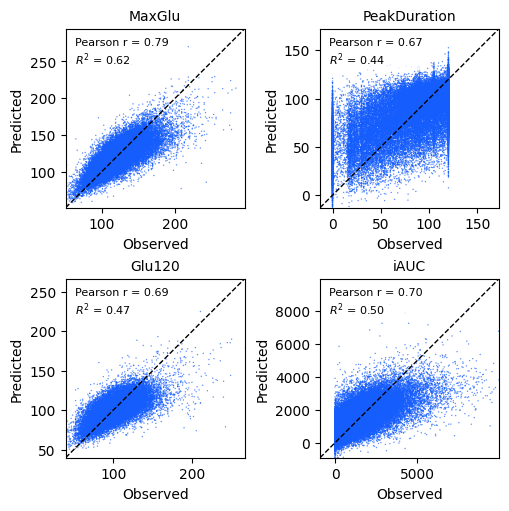

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

model = "MMER_XGBoost"



rename_metrics = {
    "max_glucose": "MaxGlu",
    "end_glucose": "Glu120",
    "peak_duration": "PeakDuration",
    "positive_iAUC": "iAUC",
}



fig, axes = plt.subplots(2, 2, figsize=(5, 5), constrained_layout=True)
axes = axes.ravel()

handles = labels = None
for ax, metric in zip(axes, prediction_metrics):
    t = f"{model}__{metric}__true"
    p = f"{model}__{metric}__pred"
    s = data[[t, p, "standardized_meal_id"]].dropna()

    vals = np.concatenate([s[t].values, s[p].values])
    lo = np.percentile(vals, 0.01)
    hi = np.percentile(vals, 99.99) + 30

    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    sns.reset_defaults()

    sns.scatterplot(
        data=s,
        x=t,
        y=p,
        s=1,
        alpha=0.7,
        edgecolor="none",
        color="#155DFC",
        ax=ax,
    )

    r, _ = pearsonr(s[t], s[p])
    r2 = r2_score(s[t], s[p])

    ax.text(
        0.05, 0.95,
        f"Pearson r = {r:.2f}\n$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(rename_metrics[metric], fontsize=10)
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")

plt.show()

In [11]:
"""
Four-panel summary figure for the PPGR modelling section.

Input: the `data` DataFrame produced by the CV analysis, with
namespaced columns  f"{model}__{metric}__{suffix}"  with
suffix in {true, pred, true_z, pred_z}, plus an `is_standardized_meal` flag.

    from ppgr_panel import plot_panel
    fig = plot_panel(data)
    fig.savefig(FIGURES_DIR / "figure_performance.pdf", bbox_inches="tight")

Panels:
  (a) global multivariate R2 per model, all vs standardized meals
  (b) outcome-specific R2 heatmap (models x outcomes)
  (c) decomposition: linear -> +nonlinear -> +individualization
  (d) predicted vs observed per outcome, 2x2 grid, standardized meals
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

# ---- display config --------------------------------------------------------
MODEL_ORDER = ["LR", "LMMER_full", "XGBoost", "MMER_XGBoost_MI", "MMER_XGBoost"]
MODEL_LABELS = {
    "LR":              "Linear\nRegression",
    "LMMER_rand_int":  "LMMER\n(RI)",
    "LMMER_full":      "LMMER\n(RI+RS)",
    "XGBoost":         "XGBoost",
    "MMER_XGBoost_MI": "MMER-XGB\n(RI)",
    "MMER_XGBoost":    "MMER-XGB\n(RI+RS)",
}
METRIC_ORDER  = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]
METRIC_LABELS = {"max_glucose": "MaxGlu", "peak_duration": "PeakDur",
                 "end_glucose": "Glu120", "positive_iAUC": "iAUC"}

C_ALL, C_STD = "#3b6ea5", "#d1495b"     # free-living / standardized
C_SCATTER = "#155DFC"                    # panel (d) points

# ---- metrics ---------------------------------------------------------------
def _multivariate_r2(df, model, metrics, multioutput="uniform_average"):
    tcols = [f"{model}__{m}__true" for m in metrics]
    pcols = [f"{model}__{m}__pred" for m in metrics]
    if set(tcols + pcols) - set(df.columns):
        return np.nan
    s = df[tcols + pcols].dropna()
    if len(s) < 3:
        return np.nan
    return r2_score(s[tcols].to_numpy(), s[pcols].to_numpy(),
                    multioutput=multioutput)

def _metric_r2(df, model, metric):
    tcol, pcol = f"{model}__{metric}__true", f"{model}__{metric}__pred"
    if {tcol, pcol} - set(df.columns):
        return np.nan
    s = df[[tcol, pcol]].dropna()
    return r2_score(s[tcol], s[pcol]) if len(s) >= 3 else np.nan


def plot_panel(data, std_col="is_standardized_meal",
               metrics=METRIC_ORDER, multioutput="uniform_average"):
    models = [m for m in MODEL_ORDER
              if any(c.startswith(m + "__") for c in data.columns)]
    subsets = {"All meals": data}
    if std_col in data.columns:
        subsets["Standardized meals"] = data[data[std_col] == 1]
    has_std = "Standardized meals" in subsets

    plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                         "axes.spines.right": False})
    fig = plt.figure(figsize=(9, 8))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.32, wspace=0.35)
    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    # panel (d) is a nested 2x2 grid inside the bottom-right cell
    gs_d = gs[1, 1].subgridspec(2, 2, hspace=0.50, wspace=0.5)
    axD = np.empty((2, 2), dtype=object)
    for i in range(2):
        for j in range(2):
            axD[i, j] = fig.add_subplot(gs_d[i, j])

    # ---- (a) global multivariate R2 ---------------------------------------
    x = np.arange(len(models)); w = 0.38
    for i, (name, df) in enumerate(subsets.items()):
        vals = [_multivariate_r2(df, m, metrics, multioutput) for m in models]
        off = (i - (len(subsets) - 1) / 2) * w
        bars = axA.bar(x + off, vals, w, label=name,
                       color=C_ALL if name == "All meals" else C_STD)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                axA.text(b.get_x() + b.get_width() / 2,
                         v + (0.015 if v >= 0 else -0.045), f"{v:.2f}",
                         ha="center", va="bottom" if v >= 0 else "top", fontsize=7)
    axA.axhline(0, color="0.4", lw=0.8)
    axA.set_xticks(x); axA.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=7)
    axA.set_ylabel("Multivariate $R^2$")
    axA.set_ylim([-0.5, 0.75])
    axA.legend(frameon=False, fontsize=8, loc="upper left")


    # ---- (b) decomposition ------------------------------------------------
    levels = ["LR", "XGBoost", "MMER_XGBoost"]
    xlabels = ["Linear\n(LR)", "+ Nonlinear\n(XGBoost)", "+ Individualization\n(MMER-XGB)"]
    xs = np.arange(len(levels))
    for name, df in subsets.items():
        vals = [_multivariate_r2(df, m, metrics, multioutput) for m in levels]
        col = C_ALL if name == "All meals" else C_STD
        axB.plot(xs, vals, "-o", color=col, label=name, lw=2, ms=7)
        for k in range(1, len(vals)):
            if not (np.isnan(vals[k]) or np.isnan(vals[k - 1])):
                d = np.round(vals[k],2) - np.round(vals[k - 1],2)
                axB.annotate(f"+{d:.2f}" if d >= 0 else f"{d:.2f}",
                             ((xs[k - 1] + xs[k]) / 2, (vals[k] + vals[k - 1]) / 2),
                             xytext=(0, 8 if col == C_ALL else -12),
                             textcoords="offset points", ha="center",
                             fontsize=7, color=col)
    axB.axhline(0, color="0.4", lw=0.8)
    axB.set_xticks(xs); axB.set_xticklabels(xlabels, fontsize=8)
    axB.set_ylim([-0.23,0.70])
    axB.set_ylabel("Multivariate $R^2$")
    axB.legend(frameon=False, fontsize=8, loc="upper left")

    # ---- (b) outcome-specific R2 heatmap (free-living) --------------------
    ref = subsets["All meals"]
    M = np.array([[_metric_r2(ref, mdl, met) for mdl in models] for met in metrics])
    im = axC.imshow(M, cmap="BuPu", vmin=0, vmax=1, aspect="auto")
    axC.set_xticks(range(len(models)))
    axC.set_xticklabels([MODEL_LABELS[m] for m in models],
                    rotation=0, ha="center", fontsize=7)
    axC.set_yticks(range(len(metrics)))
    axC.set_yticklabels([METRIC_LABELS[m] for m in metrics])
    for i in range(len(metrics)):
        for j in range(len(models)):
            if not np.isnan(M[i, j]):
                axC.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                         fontsize=7.5, color="black")
    fig.colorbar(im, ax=axC, fraction=0.046, pad=0.04, label="$R^2$")

    # ---- (d) predicted vs observed per outcome, 2x2, standardized ---------
    mdl = "MMER_XGBoost"
    dfd = subsets.get("Standardized meals", data)   # standardized-meal transfer
    axd_flat = axD.ravel()
    plotted = 0
    for idx in range(4):
        ax = axd_flat[idx]
        if idx >= len(metrics):
            ax.set_visible(False)
            continue
        met = metrics[idx]
        tcol, pcol = f"{mdl}__{met}__true", f"{mdl}__{met}__pred"
        if {tcol, pcol} - set(dfd.columns):
            ax.set_visible(False)
            continue
        s = dfd[[tcol, pcol]].dropna()
        if len(s) < 3:
            ax.set_visible(False)
            continue

        vals = np.concatenate([s[tcol].to_numpy(), s[pcol].to_numpy()])
        lo, hi = np.percentile(vals, 0.01), np.percentile(vals, 99.99)
        pad = 0.05 * (hi - lo) if hi > lo else 1.0     # relative, metric-agnostic
        lo, hi = lo - pad, hi + pad

        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        ax.scatter(s[tcol], s[pcol], s=3, alpha=0.6, color=C_SCATTER,
                   edgecolors="none", zorder=2)

        r, _ = pearsonr(s[tcol], s[pcol])
        r2 = r2_score(s[tcol], s[pcol])
        ax.text(0.05, 0.95, f"r = {r:.2f}\n$R^2$ = {r2:.2f}",
                transform=ax.transAxes, ha="left", va="top", fontsize=7,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="none"))

        if idx==1:
            hi=210
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(METRIC_LABELS.get(met, met), fontsize=8)
        ax.tick_params(labelsize=6)
        row, col = divmod(idx, 2)
        if row == 1:
            ax.set_xlabel("Observed", fontsize=7)
        if col == 0:
            ax.set_ylabel("Predicted", fontsize=7)
        plotted += 1

    if plotted == 0:
        for ax in axd_flat:
            ax.set_visible(False)

    # panel (d) header sits above the 2x2 block
    pos = gs[1, 1].get_position(fig)
    #fig.text(pos.x0, pos.y1 + 0.035, "d  Standardized-meal transfer",
    #         ha="left", va="bottom", fontweight="bold")
    return fig

fig = plot_panel(data)                       # uses is_standardized_meal

fig.savefig(
    FIGURES_DIR / "panel_2_model_comparison.svg",
    format="svg",
    bbox_inches="tight")

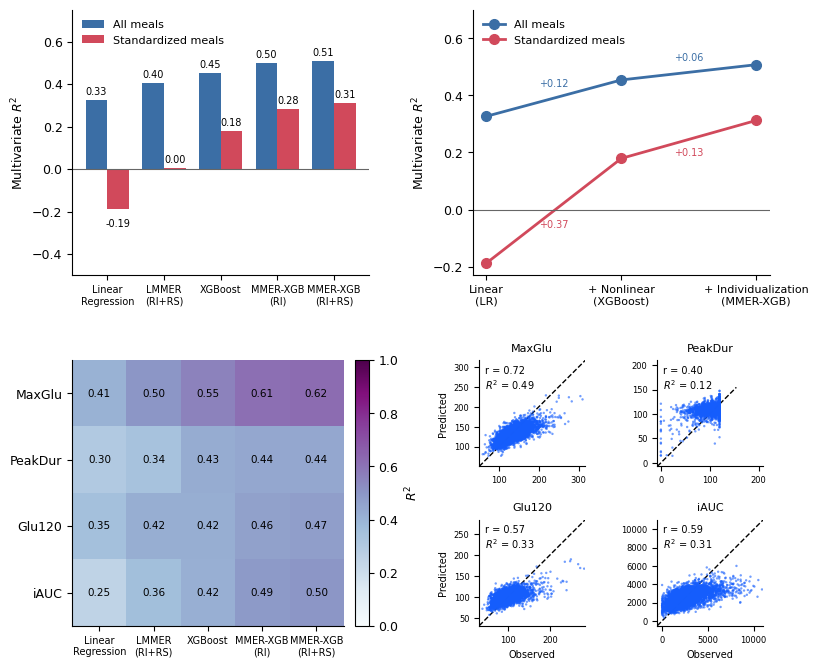

In [12]:
fig

In [13]:
# participant-level covariates
subjects = (
    data[data["is_standardized_meal"]==False].groupby("subject_key", as_index=False)
        .agg(
            age=("age", "first"),
            bmi=("bmi", "first"),
            gender=("gender", "first"),
            mean_positive_iAUC=("positive_iAUC", "mean"),
        )
)
subjects["age_tertile"] = pd.qcut(subjects["age"], 3, labels=["T1", "T2", "T3"])
subjects["bmi_tertile"] = pd.qcut(subjects["bmi"], 3, labels=["T1", "T2", "T3"])
subjects["ppgr_tertile"] = pd.qcut(subjects["mean_positive_iAUC"], 3, labels=["T1", "T2", "T3"])
## merge tertiles back to meal-level data
data = data.merge(
    subjects[[
        "subject_key", "age_tertile", "bmi_tertile", "ppgr_tertile"]],
    on="subject_key",
    how="left",
)
rows = []

for subgroup in ["gender", "age_tertile", "bmi_tertile", "ppgr_tertile"]:
    for level, df_sub in data.groupby(subgroup):
        #for meal in ["A", "B", "C"]:
        df = df_sub.copy()#[df_sub["standardized_meal_id"] == meal]
        cols_true = [f"MMER_XGBoost__{m}__true" for m in prediction_metrics]
        cols_pred = [f"MMER_XGBoost__{m}__pred" for m in prediction_metrics]
        sub = df[cols_true + cols_pred].dropna()
        rows.append({
            "subgroup": subgroup,
            "level": level,
            #"meal": meal,
            "n": len(sub),
            "R2": np.round(r2_score(
                sub[cols_true],
                sub[cols_pred],
                multioutput="uniform_average",
            ),2),
        })

results = pd.DataFrame(rows)
print(results)

[notebook cell]:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for level, df_sub in data.groupby(subgroup):
[notebook cell]:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for level, df_sub in data.groupby(subgroup):
[notebook cell]:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for level, df_sub in data.groupby(subgroup):


        subgroup level      n    R2
0         gender     0  34171  0.50
1         gender     1  20816  0.50
2    age_tertile    T1  19275  0.49
3    age_tertile    T2  19553  0.49
4    age_tertile    T3  16159  0.53
5    bmi_tertile    T1  18906  0.49
6    bmi_tertile    T2  18719  0.50
7    bmi_tertile    T3  17362  0.52
8   ppgr_tertile    T1  19014  0.46
9   ppgr_tertile    T2  18686  0.48
10  ppgr_tertile    T3  17287  0.50


In [14]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

rows = []

for id_ in ["A", "B", "C"]:
    for m in prediction_metrics:
        sub_df=data[(data["standardized_meal_id"]==id_)
        ]
        sub = sub_df[[f"MMER_XGBoost__{m}__true", f"MMER_XGBoost__{m}__pred"]].dropna()   # validated rows only
        yt, yp = sub[f"MMER_XGBoost__{m}__true"], sub[f"MMER_XGBoost__{m}__pred"]
        r, p = pearsonr(yt, yp)
        rows.append({
            "id": id_,
            "metric": m,
            "n": len(sub),
            "r2": np.round(r2_score(yt, yp), 2),
            "pearson_r": np.round(r, 2),
            "pearson_p": p,
        })

scores = pd.DataFrame(rows).set_index("metric")
print(scores[scores["id"]!="other"])

              id     n    r2  pearson_r      pearson_p
metric                                                
max_glucose    A  1766  0.30       0.63  8.591188e-198
peak_duration  A  1766  0.17       0.48  3.127477e-103
end_glucose    A  1766  0.25       0.50  5.547708e-112
positive_iAUC  A  1766  0.17       0.52  2.287829e-122
max_glucose    B  1465  0.43       0.67  1.812873e-189
peak_duration  B  1465  0.12       0.40   1.524967e-56
end_glucose    B  1465  0.37       0.61  1.283012e-150
positive_iAUC  B  1465  0.22       0.47   4.669017e-80
max_glucose    C  1293  0.48       0.69  8.904189e-186
peak_duration  C  1293  0.06       0.30   2.848208e-28
end_glucose    C  1293  0.42       0.65  4.553145e-156
positive_iAUC  C  1293  0.24       0.49   1.106907e-79


In [15]:
# Participant-specific prediction performance

prediction_metrics = [
    "max_glucose",
    "peak_duration",
    "end_glucose",
    "positive_iAUC",
]

def evaluate_subjects(data, models, metrics, subject_col="subject_key"):
    rows = []
    for model in tqdm(models):
        tcols = [f"{model}__{m}__true" for m in metrics]
        pcols = [f"{model}__{m}__pred" for m in metrics]

        # per-metric R2 (independent NaN mask per metric)
        for metric, tcol, pcol in zip(metrics, tcols, pcols):
            if {tcol, pcol, subject_col} - set(data.columns):
                continue
            for subject, df_sub in data.groupby(subject_col):
                s = df_sub[[tcol, pcol]].dropna()
                if len(s) < 3:
                    continue
                r, _ = pearsonr(s[tcol], s[pcol])
                rows.append({
                    "Model": model, "Metric": metric, "subject_key": subject,
                    "n": len(s), "R2": r2_score(s[tcol], s[pcol]), "Pearson_r": r,
                })

        # global multivariate R2 (common NaN mask across all outcomes)
        if (set(tcols) | set(pcols) | {subject_col}) - set(data.columns):
            continue
        for subject, df_sub in data.groupby(subject_col):
            s = df_sub[tcols + pcols].dropna()
            if len(s) < 3:
                continue
            rows.append({
                "Model": model, "Metric": "global", "subject_key": subject,
                "n": len(s),
                "R2": r2_score(s[tcols].to_numpy(), s[pcols].to_numpy(),
                               multioutput="uniform_average"),
                "Pearson_r": np.nan,
            })
    return pd.DataFrame(rows)

subject_perf = evaluate_subjects(data, run_tags, prediction_metrics)

summary = (
    subject_perf
    .groupby(["Metric", "Model"])
    .agg(
        mean_R2=("R2", "mean"), median_R2=("R2", "median"),
        min_R2=("R2", "min"), max_R2=("R2", "max"),
        mean_r=("Pearson_r", "mean"), median_r=("Pearson_r", "median"),
        min_r=("Pearson_r", "min"), max_r=("Pearson_r", "max"),
    )
    .reset_index()
)
summary["R²"] = summary.apply(
    lambda x: f"{x['mean_R2']:.2f} ({x['min_R2']:.2f}–{x['max_R2']:.2f})", axis=1,
)

summary["Pearson r"] = summary.apply(
    lambda x: f"{x['median_r']:.2f} ({x['min_r']:.2f};{x['max_r']:.2f})", axis=1,
)
final_table = (
    summary[["Metric", "Model", "R²", "Pearson r"]]
    .pivot(index="Metric", columns="Model")
)

100%|██████████| 6/6 [00:42<00:00,  7.10s/it]


In [16]:
final_table["R²"]

Model,LMMER_full,LMMER_rand_int,LR,MMER_XGBoost,MMER_XGBoost_MI,XGBoost
Metric,,,,,,
end_glucose,0.10 (-1.03–0.64),0.09 (-2.94–0.54),-0.01 (-9.33–0.69),0.17 (-0.69–0.70),0.16 (-0.72–0.71),0.10 (-2.01–0.70)
global,0.22 (-1.54–0.53),0.21 (-3.10–0.49),0.12 (-8.19–0.51),0.35 (-0.35–0.64),0.34 (-0.66–0.64),0.27 (-1.47–0.60)
max_glucose,0.23 (-0.78–0.81),0.21 (-2.32–0.81),0.09 (-7.98–0.80),0.40 (-0.69–0.83),0.39 (-1.07–0.82),0.30 (-1.51–0.79)
peak_duration,0.31 (-1.94–0.73),0.30 (-6.50–0.73),0.26 (-11.34–0.71),0.41 (-0.30–0.80),0.41 (-0.35–0.80),0.39 (-0.47–0.80)
positive_iAUC,0.26 (-3.46–0.67),0.24 (-3.74–0.59),0.13 (-10.97–0.58),0.40 (-0.93–0.80),0.39 (-1.59–0.77),0.30 (-4.56–0.73)


In [17]:
import statsmodels.formula.api as smf

sub_df = subject_perf[(subject_perf["Metric"]=="global")&(
    subject_perf["Model"].isin(["LR", "XGBoost", "MMER_XGBoost", "MMER_XGBoost_MI"]))].copy()
result = smf.mixedlm(
    "R2 ~ C(Model)+  n",
    data=sub_df,
    groups=sub_df["subject_key"],
).fit()

print(result.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      R2      
No. Observations:      3968         Method:                  REML    
No. Groups:            992          Scale:                   0.0307  
Min. group size:       4            Log-Likelihood:          592.2374
Max. group size:       4            Converged:               Yes     
Mean group size:       4.0                                           
---------------------------------------------------------------------
                            Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.060    0.018  3.445 0.001  0.026  0.095
C(Model)[T.MMER_XGBoost]    0.227    0.008 28.808 0.000  0.211  0.242
C(Model)[T.MMER_XGBoost_MI] 0.219    0.008 27.759 0.000  0.203  0.234
C(Model)[T.XGBoost]         0.150    0.008 19.108 0.000  0.135  0.166
n                           0.001   